<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# 🤗 **Transfer Learning con Hugging Face para Auditores Bancarios**

## Objetivo del notebook

Este notebook introduce el **Transfer Learning** aplicado a modelos de visión y documentos usando **Hugging Face Transformers**, con especial atención al modelo **Donut** (*Document Understanding Transformer*).

En auditoría bancaria, el objetivo no es clasificar imágenes genéricas, sino automatizar tareas sobre **documentos financieros**:

- Facturas.
- Recibos.
- Justificantes de transferencia.
- Cheques.
- Documentos KYC.
- Extractos bancarios.
- Capturas de banca electrónica.
- Evidencias de operaciones sospechosas.

La idea principal es aprovechar modelos ya preentrenados sobre grandes colecciones de documentos y adaptarlos a un caso bancario concreto.

---

## ¿Por qué Transfer Learning en auditoría?

Entrenar un modelo documental desde cero suele ser inviable porque requiere:

- Miles o millones de documentos etiquetados.
- Mucho tiempo de entrenamiento.
- GPUs potentes.
- Conocimiento experto en visión, texto y NLP.

Con **Transfer Learning**, partimos de un modelo que ya ha aprendido patrones generales:

- Estructura visual de documentos.
- Zonas de texto.
- Tablas.
- Cabeceras.
- Campos clave.
- Distribución espacial.
- Relación entre imagen y contenido textual.

Después lo adaptamos con pocos datos etiquetados del banco.


## 1. FUNDAMENTOS TEÓRICOS


### 1.1 ¿Qué es Transfer Learning?

El **Transfer Learning** consiste en reutilizar un modelo entrenado previamente en una tarea grande y general, y adaptarlo a una tarea nueva más específica.

En lugar de empezar desde cero, aprovechamos el conocimiento aprendido por el modelo.

Ejemplo:

1. Un modelo aprende de millones de documentos genéricos.
2. El banco lo adapta a sus propios documentos.
3. El modelo aprende diferencias específicas:
   - facturas válidas frente a facturas sospechosas,
   - justificantes reales frente a justificantes alterados,
   - documentos KYC completos frente a incompletos,
   - extractos bancarios normales frente a extractos inconsistentes.


### 1.2 Transfer Learning frente a entrenamiento desde cero

| Enfoque | Ventajas | Inconvenientes |
|---|---|---|
| Entrenar desde cero | Control total del modelo | Coste muy alto, necesita muchísimos datos |
| Transfer Learning | Menos datos, menor coste, mejor punto de partida | Requiere adaptar correctamente el modelo |
| Feature extraction | Rápido y estable | Menos flexible |
| Fine-tuning completo | Mejor adaptación | Mayor riesgo de sobreajuste |
| Fine-tuning parcial | Equilibrio entre estabilidad y adaptación | Requiere decidir qué capas entrenar |


### 1.3 ¿Qué es Hugging Face?

**Hugging Face** es un ecosistema para usar modelos preentrenados de Machine Learning, especialmente modelos de:

- NLP.
- Visión por computador.
- Audio.
- Modelos multimodales.
- Document AI.
- LLMs.

En este notebook se usará la librería `transformers`, junto con `datasets`, `torch` y modelos como:

- `Donut`: comprensión de documentos sin OCR explícito.
- `ViT`: clasificación de imágenes mediante Transformers.
- `LayoutLM` / `LayoutLMv3`: documentos con texto OCR + layout.


### 1.4 ¿Qué es Donut?

**Donut** significa **Document Understanding Transformer**.

Es un modelo diseñado para comprender documentos directamente desde la imagen.

Su característica más importante es que puede trabajar **sin un OCR externo tradicional**.

En lugar de hacer:

```text
Imagen → OCR → Texto → Modelo NLP
```

Donut intenta hacer:

```text
Imagen del documento → Modelo Donut → Salida estructurada
```

Por ejemplo:

```json
{
  "tipo_documento": "factura",
  "importe": "1250.40",
  "fecha": "2026-04-18",
  "proveedor": "ACME S.L.",
  "riesgo": "medio"
}
```


### 1.5 Diferencia entre Donut, ViT y LayoutLM

| Modelo | Entrada | Salida típica | Uso en auditoría |
|---|---|---|---|
| CNN clásica | Imagen | Clase | Clasificar documento |
| ViT | Imagen | Clase | Clasificar documentos o calidad |
| Donut | Imagen | Texto/JSON | Extraer campos y clasificar documentos |
| LayoutLM | Texto OCR + coordenadas | Clase/campos | Analizar documentos con OCR |
| TrOCR | Imagen de texto | Texto | Reconocimiento de texto manuscrito o impreso |

Donut es especialmente interesante cuando queremos que el modelo devuelva una **respuesta estructurada**.


### 1.6 Casos de uso bancarios adecuados para Donut

Donut puede ser útil en auditoría bancaria para:

1. **Clasificación documental**
   - factura,
   - recibo,
   - transferencia,
   - cheque,
   - DNI,
   - nómina,
   - extracto.

2. **Extracción de campos**
   - importe,
   - fecha,
   - emisor,
   - beneficiario,
   - IBAN,
   - número de factura,
   - concepto.

3. **Validación documental**
   - detectar documentos incompletos,
   - detectar campos ausentes,
   - detectar formato incorrecto.

4. **Soporte a revisión manual**
   - priorizar documentos sospechosos,
   - reducir carga de revisión,
   - generar alertas explicables.

5. **Auditoría de expedientes**
   - comprobar que la documentación obligatoria está presente,
   - detectar incoherencias entre documentos,
   - identificar documentos duplicados o manipulados.


### 1.7 Cuidado: Donut no sustituye al auditor

Un modelo documental no debe considerarse una prueba definitiva.

En auditoría bancaria debe usarse como sistema de apoyo:

- priorización,
- preclasificación,
- extracción preliminar,
- detección de anomalías,
- control de calidad.

La decisión final debe conservar trazabilidad humana, especialmente en procesos regulados.


## 2. CASUÍSTICAS CLAVE PARA AUDITORES DE BANCA


### 2.1 Datos sensibles y privacidad

Los documentos bancarios suelen contener:

- nombres y apellidos,
- DNI/NIE/pasaporte,
- IBAN,
- direcciones,
- importes,
- firmas,
- datos fiscales,
- datos laborales,
- información patrimonial.

Antes de entrenar modelos se debe revisar:

- anonimización,
- minimización de datos,
- control de acceso,
- trazabilidad,
- cifrado,
- retención de datos,
- justificación legal del tratamiento.


### 2.2 Riesgos de fuga de información

Nunca deben subirse documentos reales del banco a servicios externos sin autorización.

Buenas prácticas:

- trabajar en entorno corporativo seguro,
- usar modelos descargados localmente,
- anonimizar documentos,
- usar datasets sintéticos o enmascarados,
- separar entornos de desarrollo y producción,
- registrar quién accede a los datos.


### 2.3 Sesgos documentales

El modelo puede aprender sesgos no deseados:

- documentos de ciertos países peor reconocidos,
- plantillas antiguas peor tratadas,
- fotos móviles con peor rendimiento,
- documentos en otros idiomas peor clasificados,
- formatos minoritarios ignorados.

Por eso hay que evaluar por segmentos:

- tipo de documento,
- oficina,
- país,
- canal,
- calidad de imagen,
- idioma,
- antigüedad del formato.


### 2.4 Calidad de imagen

En documentos bancarios, la calidad visual afecta muchísimo:

- baja resolución,
- rotación,
- sombras,
- reflejos,
- documentos cortados,
- fondos complejos,
- compresión excesiva,
- escaneos borrosos.

Un modelo puede fallar no porque el caso sea complejo, sino porque la imagen no contiene suficiente información.


### 2.5 Drift documental

Los documentos cambian con el tiempo:

- nuevas plantillas,
- cambios de proveedores,
- nuevas normativas,
- logos actualizados,
- nuevos campos obligatorios,
- digitalización de procesos.

Esto genera **data drift** y **concept drift**.

Un modelo entrenado en documentos de 2024 puede degradarse en documentos de 2026 si el formato cambia.


### 2.6 Métricas relevantes en auditoría documental

No basta con mirar la accuracy.

Métricas recomendadas:

- matriz de confusión,
- recall por clase,
- precision por clase,
- F1-score macro,
- F1-score weighted,
- tasa de falsos negativos,
- tasa de falsos positivos,
- revisión manual requerida,
- coste esperado del error,
- rendimiento por segmento.


### 2.7 Interpretabilidad y trazabilidad

En auditoría no basta decir:

> "El modelo predice que es sospechoso".

Hay que documentar:

- qué imagen entró,
- qué versión del modelo se usó,
- qué salida generó,
- qué confianza tenía,
- qué reglas posteriores se aplicaron,
- qué auditor revisó el caso,
- qué decisión final se tomó.


## 3. PREPARACIÓN DEL ENTORNO


In [1]:
# Si estás ejecutando este notebook por primera vez, puede que necesites instalar:
# !pip install transformers datasets accelerate evaluate sentencepiece protobuf pillow scikit-learn matplotlib pandas numpy torch torchvision
# !pip install seqeval
# !pip install jiwer

# Para usar Donut con GPU se recomienda:
# - Python 3.10 o 3.11
# - PyTorch con CUDA si hay GPU disponible
# - Al menos 8-12 GB de VRAM para pruebas cómodas


In [2]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw, ImageFont

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Entorno base preparado.")


Entorno base preparado.


In [3]:
# Comprobación opcional de PyTorch y GPU
try:
    import torch
    print("PyTorch:", torch.__version__)
    print("CUDA disponible:", torch.cuda.is_available())
    device = "cuda" if torch.cuda.is_available() else "cpu"
except Exception as e:
    print("PyTorch no está disponible o no se ha podido cargar:", e)
    device = "cpu"

device


PyTorch: 2.11.0+cpu
CUDA disponible: False


'cpu'

## 4. CREACIÓN DE UN DATASET SINTÉTICO DE DOCUMENTOS BANCARIOS

Para que el notebook sea ejecutable sin datos reales del banco, generaremos documentos sintéticos.

Simularemos cuatro tipos:

1. `factura`
2. `justificante_transferencia`
3. `cheque`
4. `documento_kyc`

Esto no sustituye datos reales, pero permite aprender el flujo técnico.


In [4]:
BASE_DIR = Path("datos_sinteticos_transfer_learning_banca")
IMG_DIR = BASE_DIR / "imagenes"
IMG_DIR.mkdir(parents=True, exist_ok=True)

clases = ["factura", "justificante_transferencia", "cheque", "documento_kyc"]

plantillas = {
    "factura": [
        "FACTURA",
        "Proveedor: Servicios Financieros ACME S.L.",
        "Nº Factura: F-{id}",
        "Fecha: {fecha}",
        "Importe total: {importe} EUR",
        "IVA: {iva} EUR",
        "Cliente: Empresa Cliente S.A."
    ],
    "justificante_transferencia": [
        "JUSTIFICANTE DE TRANSFERENCIA",
        "Ordenante: Cliente Banco",
        "Beneficiario: Proveedor Externo",
        "IBAN destino: ES{id} 2100 1234 5678",
        "Fecha operación: {fecha}",
        "Importe transferido: {importe} EUR",
        "Concepto: Pago servicios"
    ],
    "cheque": [
        "CHEQUE BANCARIO",
        "Páguese a: Beneficiario Ejemplo",
        "Cantidad: {importe} EUR",
        "Fecha emisión: {fecha}",
        "Entidad: Banco Ejemplo",
        "Firma autorizada: ___________",
        "Nº cheque: CH-{id}"
    ],
    "documento_kyc": [
        "DOCUMENTO KYC",
        "Nombre: Cliente Sintético",
        "Identificación: ID-{id}",
        "Fecha alta: {fecha}",
        "Dirección: Calle Auditoría 123",
        "País: España",
        "Estado verificación: Completo"
    ]
}

def crear_documento_sintetico(tipo, idx, ancho=900, alto=1200):
    img = Image.new("RGB", (ancho, alto), color=(255, 255, 255))
    draw = ImageDraw.Draw(img)

    # Fuente por defecto
    try:
        font_title = ImageFont.truetype("DejaVuSans-Bold.ttf", 36)
        font_text = ImageFont.truetype("DejaVuSans.ttf", 24)
        font_small = ImageFont.truetype("DejaVuSans.ttf", 18)
    except:
        font_title = ImageFont.load_default()
        font_text = ImageFont.load_default()
        font_small = ImageFont.load_default()

    # Bordes y zonas
    draw.rectangle([40, 40, ancho-40, alto-40], outline=(0, 0, 0), width=3)
    draw.rectangle([60, 70, ancho-60, 170], outline=(80, 80, 80), width=2)

    fecha = f"2026-{random.randint(1,12):02d}-{random.randint(1,28):02d}"
    importe = f"{random.randint(100, 15000)}.{random.randint(0,99):02d}"
    iva = f"{float(importe)*0.21:.2f}"

    lineas = [
        l.format(id=idx, fecha=fecha, importe=importe, iva=iva)
        for l in plantillas[tipo]
    ]

    y = 95
    draw.text((90, y), lineas[0], fill=(0, 0, 0), font=font_title)

    y = 230
    for linea in lineas[1:]:
        draw.text((90, y), linea, fill=(20, 20, 20), font=font_text)
        y += 65

    # Elementos visuales diferentes por clase
    if tipo == "factura":
        draw.rectangle([90, 700, ancho-90, 950], outline=(0, 0, 0), width=2)
        for row in range(4):
            draw.line([90, 760 + row*45, ancho-90, 760 + row*45], fill=(0,0,0), width=1)
        draw.text((110, 720), "Concepto        Cantidad        Precio", fill=(0,0,0), font=font_small)

    elif tipo == "justificante_transferencia":
        draw.rectangle([90, 650, ancho-90, 780], outline=(0, 0, 0), width=2)
        draw.text((120, 690), "OPERACIÓN CONFIRMADA", fill=(0,0,0), font=font_title)

    elif tipo == "cheque":
        draw.rectangle([90, 650, ancho-90, 850], outline=(0, 0, 0), width=3)
        draw.line([120, 790, ancho-120, 790], fill=(0,0,0), width=2)
        draw.text((120, 810), "Firma", fill=(0,0,0), font=font_small)

    elif tipo == "documento_kyc":
        draw.rectangle([90, 620, 330, 900], outline=(0, 0, 0), width=2)
        draw.ellipse([150, 670, 270, 790], outline=(0,0,0), width=2)
        draw.rectangle([150, 800, 270, 870], outline=(0,0,0), width=2)
        draw.text((380, 680), "Verificación identidad", fill=(0,0,0), font=font_text)

    # Ruido visual moderado
    for _ in range(random.randint(5, 20)):
        x1, y1 = random.randint(50, ancho-50), random.randint(50, alto-50)
        x2, y2 = x1 + random.randint(-20, 20), y1 + random.randint(-20, 20)
        draw.line([x1, y1, x2, y2], fill=(220, 220, 220), width=1)

    return img

registros = []
n_por_clase = 60

for tipo in clases:
    for i in range(n_por_clase):
        idx = f"{tipo}_{i:03d}"
        img = crear_documento_sintetico(tipo, idx)
        path = IMG_DIR / f"{idx}.png"
        img.save(path)
        registros.append({"image_path": str(path), "label": tipo})

df = pd.DataFrame(registros)
df.head()


,image_path,label
0,datos_sinteticos_transfer_learning_banca\image...,factura
1,datos_sinteticos_transfer_learning_banca\image...,factura
2,datos_sinteticos_transfer_learning_banca\image...,factura
3,datos_sinteticos_transfer_learning_banca\image...,factura
4,datos_sinteticos_transfer_learning_banca\image...,factura


label
factura                       60
justificante_transferencia    60
cheque                        60
documento_kyc                 60
Name: count, dtype: int64


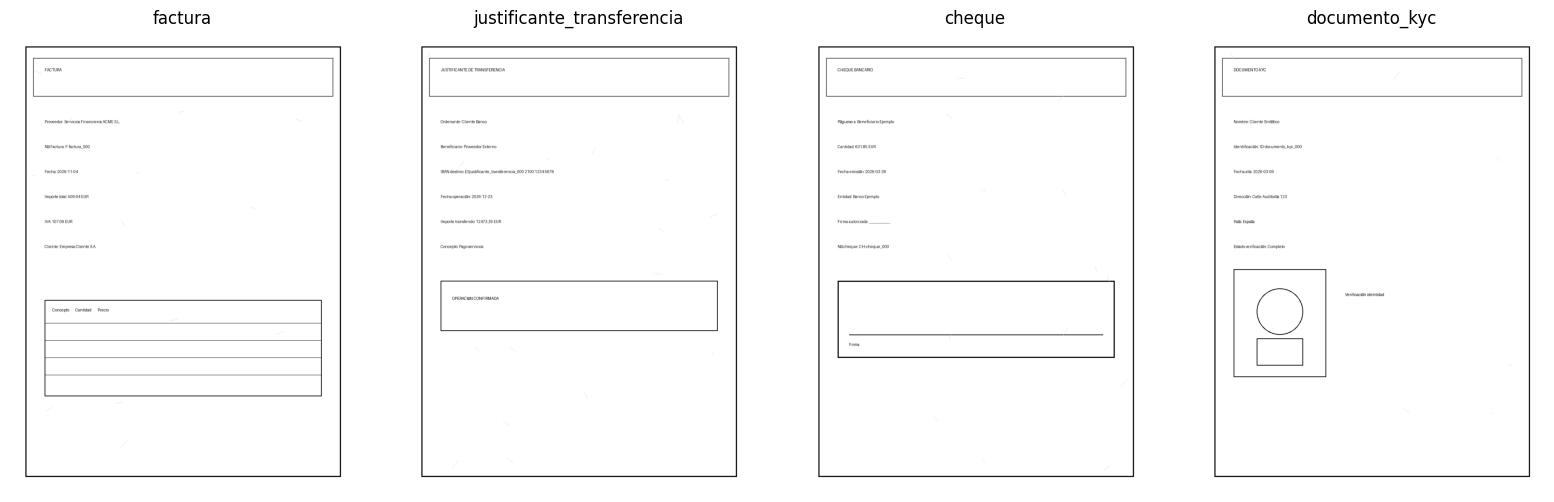

In [5]:
print(df["label"].value_counts())

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, tipo in zip(axes, clases):
    muestra = df[df["label"] == tipo].sample(1, random_state=SEED).iloc[0]
    img = Image.open(muestra["image_path"])
    ax.imshow(img)
    ax.set_title(tipo)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. OPCIÓN A: CLASIFICACIÓN DOCUMENTAL CON ViT

Antes de usar Donut, haremos un ejemplo práctico con un modelo de visión tipo **ViT**.

Esta opción es adecuada cuando el objetivo es:

- clasificar el tipo de documento,
- detectar si una imagen es válida o no,
- clasificar calidad documental,
- clasificar riesgo visual.

No extrae campos estructurados como Donut, pero es más simple.


In [6]:
# Preparación de etiquetas
label2id = {label: i for i, label in enumerate(sorted(df["label"].unique()))}
id2label = {v: k for k, v in label2id.items()}

df["label_id"] = df["label"].map(label2id)

train_df, test_df = train_test_split(
    df,
    test_size=0.25,
    stratify=df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

label2id, id2label, train_df.shape, test_df.shape


({'cheque': 0,
  'documento_kyc': 1,
  'factura': 2,
  'justificante_transferencia': 3},
 {0: 'cheque',
  1: 'documento_kyc',
  2: 'factura',
  3: 'justificante_transferencia'},
 (180, 3),
 (60, 3))

In [7]:
# Esta celda requiere transformers y torch instalados.
# El entrenamiento real puede tardar según el equipo.

try:
    from datasets import Dataset
    from transformers import AutoImageProcessor, AutoModelForImageClassification
    from transformers import TrainingArguments, Trainer
    import torch

    vit_model_name = "google/vit-base-patch16-224-in21k"
    image_processor = AutoImageProcessor.from_pretrained(vit_model_name)

    def cargar_imagen(example):
        image = Image.open(example["image_path"]).convert("RGB")
        processed = image_processor(image, return_tensors="pt")
        example["pixel_values"] = processed["pixel_values"][0]
        example["labels"] = int(example["label_id"])
        return example

    train_ds = Dataset.from_pandas(train_df).map(cargar_imagen)
    test_ds = Dataset.from_pandas(test_df).map(cargar_imagen)

    columnas = ["pixel_values", "labels"]
    train_ds.set_format(type="torch", columns=columnas)
    test_ds.set_format(type="torch", columns=columnas)

    vit_model = AutoModelForImageClassification.from_pretrained(
        vit_model_name,
        num_labels=len(label2id),
        id2label=id2label,
        label2id=label2id
    )

    print("Modelo ViT preparado correctamente.")

except Exception as e:
    print("No se pudo preparar ViT. Revisa instalación/conexión/modelo.")
    print(e)


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 10516.03it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo ViT preparado correctamente.


In [8]:
# Entrenamiento ViT
# Para una ejecución rápida en CPU, deja pocas épocas.
# En GPU se pueden aumentar épocas y batch size.

try:
    training_args = TrainingArguments(
        output_dir="vit_documentos_bancarios",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=2,
        weight_decay=0.01,
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="none"
    )

    trainer = Trainer(
        model=vit_model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=test_ds,
        processing_class=image_processor
    )

    # Descomenta para entrenar
    # trainer.train()

    print("Trainer preparado. Descomenta trainer.train() para ejecutar el fine-tuning.")

except Exception as e:
    print("No se pudo configurar el entrenamiento.")
    print(e)


Trainer preparado. Descomenta trainer.train() para ejecutar el fine-tuning.


In [9]:
# Inferencia con ViT entrenado o cargado
# Esta celda está preparada para ejecutarse después de entrenar el modelo.

def predecir_documento_vit(image_path, model=None, processor=None):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(image, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0]
        pred_id = int(torch.argmax(probs))
    return {
        "prediccion": model.config.id2label[pred_id],
        "confianza": float(probs[pred_id])
    }

print("Función de inferencia preparada.")


Función de inferencia preparada.


## 6. OPCIÓN B: DONUT PARA COMPRENSIÓN DOCUMENTAL

Donut no se limita a decir:

```text
factura
```

Puede producir una salida tipo:

```json
{
  "tipo_documento": "factura",
  "fecha": "2026-04-15",
  "importe": "1420.00",
  "riesgo": "bajo"
}
```

Esto lo hace especialmente interesante para auditoría.


### 6.1 Formato de entrenamiento para Donut

Donut suele trabajar con pares:

```text
imagen_documento → secuencia_objetivo
```

La secuencia objetivo puede representar un JSON.

Ejemplo:

```json
{
  "gt_parse": {
    "tipo_documento": "factura",
    "importe": "1250.40",
    "fecha": "2026-04-18",
    "riesgo": "medio"
  }
}
```

Para fine-tuning se necesita un dataset con:

- ruta de imagen,
- texto objetivo serializado,
- etiquetas de campos,
- partición train/test.


In [10]:
# Crearemos una versión sintética del dataset con etiquetas estructuradas para Donut

def crear_gt_parse(row):
    tipo = row["label"]
    riesgo = random.choice(["bajo", "medio", "alto"])
    return {
        "tipo_documento": tipo,
        "riesgo_documental": riesgo,
        "requiere_revision_manual": "sí" if riesgo in ["medio", "alto"] else "no"
    }

df_donut = df.copy()
df_donut["gt_parse"] = df_donut.apply(crear_gt_parse, axis=1)
df_donut["ground_truth"] = df_donut["gt_parse"].apply(lambda x: json.dumps({"gt_parse": x}, ensure_ascii=False))

df_donut.head()


,image_path,label,label_id,gt_parse,ground_truth
0,datos_sinteticos_transfer_learning_banca\image...,factura,2,"{'tipo_documento': 'factura', 'riesgo_document...","{""gt_parse"": {""tipo_documento"": ""factura"", ""ri..."
1,datos_sinteticos_transfer_learning_banca\image...,factura,2,"{'tipo_documento': 'factura', 'riesgo_document...","{""gt_parse"": {""tipo_documento"": ""factura"", ""ri..."
2,datos_sinteticos_transfer_learning_banca\image...,factura,2,"{'tipo_documento': 'factura', 'riesgo_document...","{""gt_parse"": {""tipo_documento"": ""factura"", ""ri..."
3,datos_sinteticos_transfer_learning_banca\image...,factura,2,"{'tipo_documento': 'factura', 'riesgo_document...","{""gt_parse"": {""tipo_documento"": ""factura"", ""ri..."
4,datos_sinteticos_transfer_learning_banca\image...,factura,2,"{'tipo_documento': 'factura', 'riesgo_document...","{""gt_parse"": {""tipo_documento"": ""factura"", ""ri..."


In [11]:
print(df_donut.iloc[0]["ground_truth"])


{"gt_parse": {"tipo_documento": "factura", "riesgo_documental": "alto", "requiere_revision_manual": "sí"}}


### 6.2 Carga de Donut desde Hugging Face

Para pruebas se puede usar un modelo base o uno ya ajustado a documentos.

Modelos habituales:

- `naver-clova-ix/donut-base`
- `naver-clova-ix/donut-base-finetuned-docvqa`
- `naver-clova-ix/donut-base-finetuned-cord-v2`

Para auditoría bancaria real, lo correcto sería hacer fine-tuning con documentos propios anonimizados.


In [12]:
# Carga de Donut
# Esta celda puede requerir internet la primera vez para descargar el modelo.

try:
    from transformers import DonutProcessor, VisionEncoderDecoderModel
    import torch

    donut_model_name = "naver-clova-ix/donut-base"
    donut_processor = DonutProcessor.from_pretrained(donut_model_name)
    donut_model = VisionEncoderDecoderModel.from_pretrained(donut_model_name)

    donut_model.to(device)
    print("Donut cargado correctamente:", donut_model_name)

except Exception as e:
    print("No se pudo cargar Donut. Revisa instalación, conexión o memoria disponible.")
    print(e)


Loading weights: 100%|██████████| 484/484 [00:00<?, ?it/s]


Donut cargado correctamente: naver-clova-ix/donut-base


### 6.3 Inferencia básica con Donut

Donut necesita un prompt de tarea. Por ejemplo:

```text
<s_docvqa><s_question>What is the document type?</s_question><s_answer>
```

En fine-tuning propio se pueden definir tokens especiales de tarea, por ejemplo:

```text
<s_auditoria_bancaria>
```

Y entrenar el modelo para producir JSON.


In [13]:
def inferencia_donut_basica(image_path, prompt="<s_auditoria_bancaria>"):
    image = Image.open(image_path).convert("RGB")

    pixel_values = donut_processor(image, return_tensors="pt").pixel_values.to(device)

    decoder_input_ids = donut_processor.tokenizer(
        prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    outputs = donut_model.generate(
        pixel_values,
        decoder_input_ids=decoder_input_ids,
        max_length=256,
        early_stopping=True,
        pad_token_id=donut_processor.tokenizer.pad_token_id,
        eos_token_id=donut_processor.tokenizer.eos_token_id,
        use_cache=True,
        num_beams=1,
        bad_words_ids=[[donut_processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True
    )

    sequence = donut_processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(donut_processor.tokenizer.eos_token, "").replace(donut_processor.tokenizer.pad_token, "")
    return sequence

print("Función de inferencia Donut preparada. Ejecútala después de cargar el modelo.")


Función de inferencia Donut preparada. Ejecútala después de cargar el modelo.


In [14]:
# Ejemplo de uso:
# muestra = df_donut.sample(1, random_state=SEED).iloc[0]
# print(muestra["image_path"])
# print(inferencia_donut_basica(muestra["image_path"]))


In [15]:
muestra = df_donut.sample(1, random_state=SEED).iloc[0]
print(muestra["image_path"])
print(inferencia_donut_basica(muestra["image_path"]))


[transformers] The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


datos_sinteticos_transfer_learning_banca\imagenes\factura_024.png
<s_auditoria_bancaria> S_L N_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F_F:C_F:::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::


## 7. FINE-TUNING CON DONUT: ESTRUCTURA RECOMENDADA

El fine-tuning de Donut tiene más complejidad que una clasificación simple.

Flujo:

1. Preparar imágenes.
2. Crear salidas JSON esperadas.
3. Convertir JSON a secuencias de tokens.
4. Procesar imágenes con `DonutProcessor`.
5. Entrenar `VisionEncoderDecoderModel`.
6. Evaluar exactitud de campos.
7. Validar manualmente errores críticos.


In [16]:
# Dataset personalizado para Donut

try:
    from torch.utils.data import Dataset

    class DonutAuditoriaDataset(Dataset):
        def __init__(self, dataframe, processor, max_length=512):
            self.dataframe = dataframe.reset_index(drop=True)
            self.processor = processor
            self.max_length = max_length

        def __len__(self):
            return len(self.dataframe)

        def __getitem__(self, idx):
            row = self.dataframe.iloc[idx]
            image = Image.open(row["image_path"]).convert("RGB")

            pixel_values = self.processor(
                image,
                random_padding=True,
                return_tensors="pt"
            ).pixel_values.squeeze()

            target_sequence = row["ground_truth"]

            labels = self.processor.tokenizer(
                target_sequence,
                add_special_tokens=False,
                max_length=self.max_length,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            ).input_ids.squeeze()

            labels[labels == self.processor.tokenizer.pad_token_id] = -100

            return {
                "pixel_values": pixel_values,
                "labels": labels
            }

    print("Clase Dataset para Donut preparada.")

except Exception as e:
    print("No se pudo definir el Dataset de Donut.")
    print(e)


Clase Dataset para Donut preparada.


In [17]:
# División train/test para Donut

train_donut_df, test_donut_df = train_test_split(
    df_donut,
    test_size=0.25,
    stratify=df_donut["label"],
    random_state=SEED
)

train_donut_df = train_donut_df.reset_index(drop=True)
test_donut_df = test_donut_df.reset_index(drop=True)

train_donut_df.shape, test_donut_df.shape


((180, 5), (60, 5))

In [18]:
# Preparación de datasets de Donut
# Ejecutar solo si donut_processor se ha cargado correctamente.

try:
    train_donut_dataset = DonutAuditoriaDataset(train_donut_df, donut_processor)
    test_donut_dataset = DonutAuditoriaDataset(test_donut_df, donut_processor)

    ejemplo = train_donut_dataset[0]
    print(ejemplo["pixel_values"].shape)
    print(ejemplo["labels"].shape)

except Exception as e:
    print("No se pudieron crear los datasets de Donut.")
    print(e)


[transformers] Keyword argument `random_padding` is not a valid argument for this processor and will be ignored.


torch.Size([3, 2560, 1920])
torch.Size([512])


In [19]:
# Configuración de entrenamiento Donut
# Este entrenamiento puede ser pesado. En CPU puede ser muy lento.

try:
    from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

    donut_training_args = Seq2SeqTrainingArguments(
        output_dir="donut_auditoria_bancaria",
        num_train_epochs=2,
        learning_rate=5e-5,
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        weight_decay=0.01,
        logging_steps=10,
        save_steps=100,
        eval_steps=100,
        save_total_limit=2,
        predict_with_generate=True,
        fp16=torch.cuda.is_available(),
        report_to="none"
    )

    donut_trainer = Seq2SeqTrainer(
        model=donut_model,
        args=donut_training_args,
        train_dataset=train_donut_dataset,
        eval_dataset=test_donut_dataset,
        processing_class=donut_processor.tokenizer
    )

    print("Trainer de Donut preparado.")
    print("Descomenta donut_trainer.train() para entrenar.")

    # donut_trainer.train()

except Exception as e:
    print("No se pudo configurar el Trainer de Donut.")
    print(e)


Trainer de Donut preparado.
Descomenta donut_trainer.train() para entrenar.


## 8. EVALUACIÓN DE UN MODELO DOCUMENTAL

En clasificación documental, podemos usar métricas clásicas.

En extracción estructurada con Donut, hay que evaluar también los campos.


### 8.1 Métricas para clasificación documental

- Accuracy.
- Precision.
- Recall.
- F1-score.
- Matriz de confusión.
- Error por tipo de documento.
- Error por calidad visual.
- Error por canal de entrada.


                            precision    recall  f1-score   support

                    cheque       0.76      0.87      0.81        15
             documento_kyc       0.88      1.00      0.94        15
                   factura       0.91      0.67      0.77        15
justificante_transferencia       0.93      0.93      0.93        15

                  accuracy                           0.87        60
                 macro avg       0.87      0.87      0.86        60
              weighted avg       0.87      0.87      0.86        60



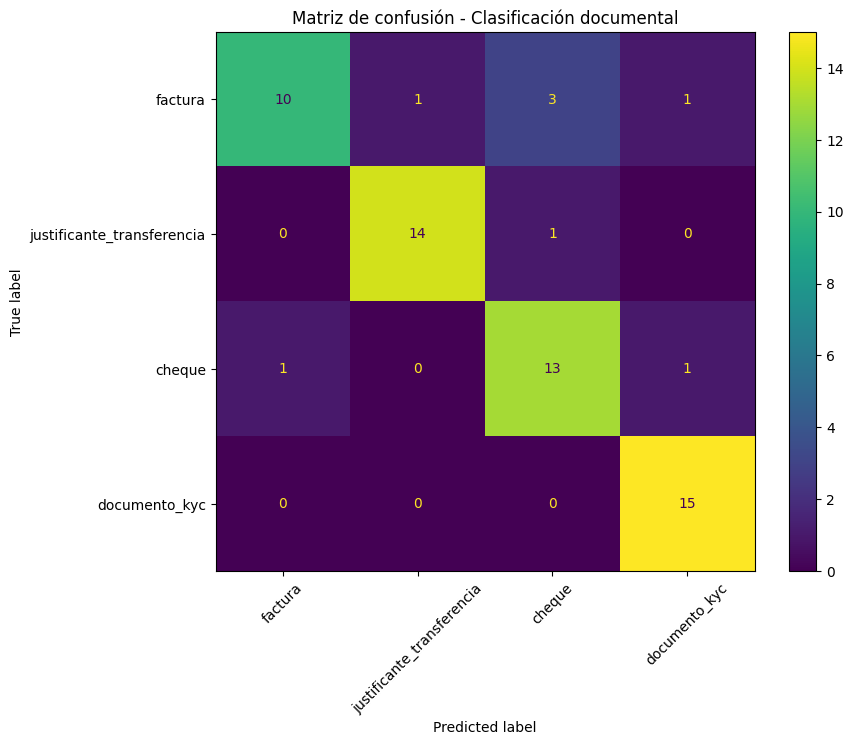

In [20]:
# Ejemplo simulado de predicciones para mostrar evaluación
# Sustituir y_pred por las predicciones reales del modelo.

y_true = test_df["label"].values

# Predicciones simuladas con alta probabilidad de acierto
rng = np.random.default_rng(SEED)
y_pred = []
for y in y_true:
    if rng.random() < 0.82:
        y_pred.append(y)
    else:
        y_pred.append(rng.choice(clases))

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred, labels=clases)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - Clasificación documental")
plt.show()


### 8.2 Métricas para extracción de campos

Para Donut, el objetivo puede ser extraer campos:

- tipo de documento,
- fecha,
- importe,
- IBAN,
- beneficiario,
- riesgo documental.

Métricas posibles:

| Métrica | Interpretación |
|---|---|
| Exact Match del JSON | Todo el JSON coincide |
| Accuracy por campo | Porcentaje de campos correctamente extraídos |
| Error de importe | Diferencia absoluta o relativa |
| Error de fecha | Fecha correcta o no |
| CER/WER | Error de caracteres o palabras |
| Tasa de campos ausentes | Campos obligatorios no detectados |


In [21]:
# Ejemplo de evaluación por campos con salidas simuladas

gt = [
    {"tipo_documento": "factura", "importe": "1200.00", "riesgo_documental": "bajo"},
    {"tipo_documento": "cheque", "importe": "5000.00", "riesgo_documental": "alto"},
    {"tipo_documento": "documento_kyc", "importe": "", "riesgo_documental": "medio"}
]

pred = [
    {"tipo_documento": "factura", "importe": "1200.00", "riesgo_documental": "bajo"},
    {"tipo_documento": "cheque", "importe": "500.00", "riesgo_documental": "alto"},
    {"tipo_documento": "documento_kyc", "importe": "", "riesgo_documental": "bajo"}
]

def evaluar_campos(gt_list, pred_list, campos):
    resultados = {}
    for campo in campos:
        aciertos = 0
        total = 0
        for g, p in zip(gt_list, pred_list):
            total += 1
            if str(g.get(campo, "")).strip() == str(p.get(campo, "")).strip():
                aciertos += 1
        resultados[campo] = aciertos / total
    return pd.DataFrame({
        "campo": list(resultados.keys()),
        "accuracy_campo": list(resultados.values())
    })

evaluar_campos(gt, pred, ["tipo_documento", "importe", "riesgo_documental"])


,campo,accuracy_campo
0,tipo_documento,1.000000
1,importe,0.666667
2,riesgo_documental,0.666667


## 9. INTERPRETACIÓN Y XAI EN MODELOS DOCUMENTALES

Aunque Donut genere texto, sigue siendo importante interpretar el proceso.

Opciones:

1. Revisar la imagen original.
2. Revisar la salida JSON.
3. Revisar la confianza o probabilidad si está disponible.
4. Comparar campos extraídos con reglas de negocio.
5. Usar atención visual si el modelo lo permite.
6. Usar técnicas de saliency/occlusion para clasificación visual.
7. Generar logs de auditoría.


### 9.1 Explicabilidad práctica para auditores

Una salida útil para auditoría debería tener este formato:

```json
{
  "tipo_documento": "justificante_transferencia",
  "importe": "4200.00",
  "fecha": "2026-04-20",
  "riesgo_documental": "medio",
  "motivos_alerta": [
    "importe elevado",
    "beneficiario no coincide con expediente",
    "documento con baja nitidez"
  ],
  "requiere_revision_manual": true
}
```

El modelo puede extraer campos, pero muchas alertas deben complementarse con reglas de negocio.


In [22]:
# Ejemplo de reglas de negocio posteriores a la predicción del modelo

def reglas_auditoria_documental(prediccion):
    alertas = []

    tipo = prediccion.get("tipo_documento", "")
    riesgo = prediccion.get("riesgo_documental", "")
    importe = prediccion.get("importe", "")

    try:
        importe_num = float(importe)
    except:
        importe_num = 0

    if tipo in ["justificante_transferencia", "cheque"] and importe_num > 10000:
        alertas.append("Importe superior a 10.000 EUR")

    if riesgo == "alto":
        alertas.append("Riesgo documental alto según el modelo")

    if tipo == "documento_kyc" and prediccion.get("fecha_caducidad", "") == "":
        alertas.append("Falta fecha de caducidad en documento KYC")

    return {
        **prediccion,
        "alertas_reglas": alertas,
        "requiere_revision_manual": len(alertas) > 0 or riesgo in ["medio", "alto"]
    }

ejemplo_pred = {
    "tipo_documento": "justificante_transferencia",
    "importe": "12500.00",
    "fecha": "2026-04-20",
    "riesgo_documental": "medio"
}

reglas_auditoria_documental(ejemplo_pred)


{'tipo_documento': 'justificante_transferencia',
 'importe': '12500.00',
 'fecha': '2026-04-20',
 'riesgo_documental': 'medio',
 'alertas_reglas': ['Importe superior a 10.000 EUR'],
 'requiere_revision_manual': True}

### 9.2 Registro de trazabilidad

En producción se debería guardar:

- ID del documento.
- Hash del fichero.
- Fecha de procesamiento.
- Versión del modelo.
- Prompt usado.
- Salida generada.
- Reglas aplicadas.
- Auditor responsable.
- Decisión final.


In [23]:
from datetime import datetime
import hashlib

def hash_fichero(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for bloque in iter(lambda: f.read(8192), b""):
            h.update(bloque)
    return h.hexdigest()

def crear_log_auditoria(documento_path, salida_modelo, version_modelo="donut-auditoria-v1"):
    return {
        "documento_path": documento_path,
        "hash_documento": hash_fichero(documento_path),
        "fecha_procesamiento": datetime.now().isoformat(),
        "version_modelo": version_modelo,
        "salida_modelo": salida_modelo
    }

muestra = df_donut.iloc[0]
log = crear_log_auditoria(
    muestra["image_path"],
    {"tipo_documento": muestra["label"], "riesgo_documental": "bajo"}
)
log


{'documento_path': 'datos_sinteticos_transfer_learning_banca\\imagenes\\factura_000.png',
 'hash_documento': 'bc9dbe436099ceb2ce3a7085bc9df4f62849c08da7b30d43400f5df09e7f43aa',
 'fecha_procesamiento': '2026-05-08T00:26:40.043320',
 'version_modelo': 'donut-auditoria-v1',
 'salida_modelo': {'tipo_documento': 'factura', 'riesgo_documental': 'bajo'}}

## 10. PIPELINE COMPLETO RECOMENDADO PARA UN BANCO


Un pipeline realista sería:

```text
1. Entrada del documento
   ↓
2. Validación técnica
   - formato
   - tamaño
   - resolución
   - legibilidad
   ↓
3. Clasificación documental
   - factura
   - cheque
   - KYC
   - transferencia
   ↓
4. Extracción de campos
   - fecha
   - importe
   - IBAN
   - emisor
   - beneficiario
   ↓
5. Reglas de negocio
   - importes elevados
   - campos obligatorios
   - coincidencia con expediente
   ↓
6. Score de riesgo documental
   ↓
7. Revisión manual si procede
   ↓
8. Registro de trazabilidad
```


In [24]:
def pipeline_documental_simulado(image_path, tipo_real=None):
    # En producción aquí irían:
    # - modelo de clasificación
    # - Donut para extracción
    # - reglas de negocio
    # - logs

    salida_modelo = {
        "tipo_documento": tipo_real if tipo_real is not None else "desconocido",
        "importe": str(random.choice([500, 1200, 3500, 12500])),
        "riesgo_documental": random.choice(["bajo", "medio", "alto"]),
        "fecha": "2026-04-20"
    }

    salida_con_reglas = reglas_auditoria_documental(salida_modelo)
    log = crear_log_auditoria(image_path, salida_con_reglas)

    return salida_con_reglas, log

muestra = df_donut.sample(1, random_state=SEED).iloc[0]
salida, log = pipeline_documental_simulado(muestra["image_path"], muestra["label"])

salida


{'tipo_documento': 'factura',
 'importe': '500',
 'riesgo_documental': 'bajo',
 'fecha': '2026-04-20',
 'alertas_reglas': [],
 'requiere_revision_manual': False}

## 11. BUENAS PRÁCTICAS DE GOBIERNO DEL MODELO


### 11.1 Antes del entrenamiento

Checklist:

- Definir objetivo exacto.
- Separar clasificación, extracción y detección de anomalías.
- Revisar base legal del tratamiento de datos.
- Anonimizar documentos siempre que sea posible.
- Etiquetar con doble revisión.
- Medir calidad del etiquetado.
- Documentar versiones de datos.


### 11.2 Durante el entrenamiento

Checklist:

- Usar partición train/validation/test.
- Evitar fuga de información.
- Separar documentos por cliente/expediente si hay duplicados.
- Controlar desbalanceo de clases.
- Monitorizar overfitting.
- Guardar configuración del entrenamiento.
- Guardar versión exacta del modelo base.


### 11.3 Después del entrenamiento

Checklist:

- Evaluar globalmente y por segmento.
- Revisar errores críticos.
- Validar con auditores.
- Crear umbrales de revisión manual.
- Documentar limitaciones.
- Preparar plan de monitorización.
- Definir cuándo reentrenar.


### 11.4 En producción

Checklist:

- Monitorizar drift.
- Registrar predicciones.
- Permitir revisión humana.
- Implementar rollback del modelo.
- Auditar accesos.
- No usar salidas del modelo sin validación en decisiones críticas.
- Revisar periódicamente falsos negativos.


## 12. COMPARATIVA FINAL DE ENFOQUES


| Necesidad bancaria | Modelo recomendado | Comentario |
|---|---|---|
| Clasificar tipo de documento | ViT / CNN / Donut | ViT suele ser más simple |
| Extraer campos estructurados | Donut / LayoutLM | Donut evita OCR externo |
| Analizar documentos con OCR corporativo | LayoutLMv3 | Muy potente si hay OCR fiable |
| Leer texto manuscrito | TrOCR | Útil para firmas o campos escritos |
| Detectar fraude visual | CNN/ViT + reglas | Requiere dataset específico |
| Automatizar revisión documental | Donut + reglas + auditor | Mejor enfoque híbrido |
| Alta explicabilidad regulatoria | Modelo + reglas + trazabilidad | No basta el modelo solo |


## 13. ERRORES COMUNES


### Error 1: Usar documentos reales sin anonimizar

Riesgo grave de privacidad.

---

### Error 2: Medir solo accuracy

En auditoría importan especialmente los falsos negativos.

---

### Error 3: Mezclar documentos del mismo expediente en train y test

Puede generar fuga de información.

---

### Error 4: Creer que Donut elimina toda necesidad de validación

Donut puede equivocarse y generar campos incorrectos.

---

### Error 5: No controlar drift documental

Los formatos cambian y el modelo se degrada.

---

### Error 6: No documentar el modelo

Un modelo no documentado es difícil de defender ante auditoría interna, compliance o regulador.


## 14. EJERCICIOS FINALES

A continuación se proponen 10 ejercicios con nuevos datos o extensiones del dataset sintético. El objetivo es que el alumno practique Transfer Learning, Hugging Face, Donut y evaluación documental en contexto bancario.


### Ejercicio 1: Nueva clase documental

Añade una nueva clase llamada `nomina`.

Debes:
1. Crear una plantilla sintética de nómina.
2. Generar al menos 40 imágenes.
3. Añadirlas al dataframe.
4. Mostrar 3 ejemplos.
5. Explicar qué campos serían relevantes para auditoría bancaria.


### Ejercicio 2: Clasificación de calidad documental

Crea una variable objetivo binaria:

- `calidad_correcta`
- `calidad_deficiente`

Simula documentos con:
- blur,
- baja resolución,
- rotación,
- recorte parcial.

Entrena un modelo para detectar si el documento necesita recaptura antes de ser revisado.


### Ejercicio 3: Fine-tuning con ViT

Realiza el fine-tuning completo de ViT con el dataset sintético.

Debes:
1. Entrenar el modelo.
2. Obtener predicciones en test.
3. Calcular matriz de confusión.
4. Interpretar qué clases se confunden más.
5. Proponer medidas de mejora.


### Ejercicio 4: Dataset para Donut

Construye un dataset Donut donde cada imagen tenga como salida:

```json
{
  "tipo_documento": "...",
  "importe": "...",
  "fecha": "...",
  "riesgo_documental": "..."
}
```

Debes explicar cómo se serializa este JSON para entrenar Donut.


### Ejercicio 5: Reglas de negocio

Diseña reglas de auditoría posteriores al modelo.

Ejemplos:
- importe superior a 10.000 EUR,
- KYC sin fecha de caducidad,
- transferencia sin beneficiario,
- factura sin número identificador.

Aplica las reglas a 20 predicciones simuladas.


### Ejercicio 6: Evaluación por campos

Crea una función que compare JSON real y JSON predicho.

Debe calcular:
- accuracy por campo,
- campos ausentes,
- campos con formato incorrecto,
- exact match completo del documento.


### Ejercicio 7: Segmentación de errores

Evalúa el rendimiento por segmentos:

- tipo de documento,
- calidad de imagen,
- canal de entrada,
- importe alto/bajo.

Explica por qué esta evaluación es más útil que una métrica global.


### Ejercicio 8: Trazabilidad del modelo

Crea una tabla de logs con:

- ID documento,
- hash,
- fecha de procesamiento,
- versión del modelo,
- predicción,
- reglas aplicadas,
- decisión final.

Explica por qué esta tabla es importante para auditoría.


### Ejercicio 9: Comparativa Donut vs OCR + reglas

Compara conceptualmente dos pipelines:

1. Donut directo sobre imagen.
2. OCR tradicional + reglas + modelo NLP.

Debes indicar ventajas, inconvenientes, riesgos y contexto donde usarías cada uno.


### Ejercicio 10: Diseño de un sistema bancario real

Diseña una arquitectura completa para revisión documental bancaria.

Debe incluir:
- entrada de documentos,
- validación técnica,
- clasificación,
- extracción,
- reglas,
- revisión humana,
- almacenamiento,
- monitorización,
- reentrenamiento.

Incluye un diagrama textual del flujo.


## 15. CONCLUSIONES

En este notebook se ha visto cómo aplicar **Transfer Learning con Hugging Face** a problemas documentales de auditoría bancaria.

Ideas clave:

1. Los modelos preentrenados reducen mucho la necesidad de datos.
2. ViT es útil para clasificación documental.
3. Donut es especialmente útil para extracción estructurada desde imágenes.
4. En banca, la privacidad y la trazabilidad son críticas.
5. La evaluación debe hacerse por clase, campo y segmento.
6. Un modelo documental debe combinarse con reglas de negocio.
7. La revisión humana sigue siendo necesaria en casos críticos.
8. La gobernanza del modelo es tan importante como la métrica técnica.

El objetivo final no es reemplazar al auditor, sino darle una herramienta que reduzca carga operativa y mejore la detección de riesgos documentales.
